In [1]:
# !rm -rf '/content/DIS_Hughen'
# !git clone https://github.com/NU-Academics/DIS_Hughen.git

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [3]:
df = pd.read_csv("undersampled_CIC2019_dataset.csv")
# df = pd.read_csv("/content/DIS_Hughen/undersampled_CIC2019_dataset.csv")

In [4]:
df.shape

(4685611, 90)

In [5]:
attack_set = df[df["label"] != "BENIGN"]
attack_sample = (attack_set.sample(n=50000, random_state=42, replace=True).reset_index(drop=True))

In [6]:
attack_sample.shape

(50000, 90)

In [7]:
print(attack_sample["label"].value_counts())

label
TFTP             10193
DrDoS_NTP         9861
DrDoS_DNS         9577
DrDoS_SNMP        4646
DrDoS_LDAP        3123
LDAP              3102
MSSQL             2062
UDP               1650
DrDoS_MSSQL       1584
DrDoS_SSDP        1180
DrDoS_UDP         1107
DrDoS_NetBIOS      722
NetBIOS            613
Syn                441
Portmap             67
UDP-lag             57
UDPLag              15
Name: count, dtype: int64


In [8]:
benign_set = df[df["label"] == "BENIGN"]
benign_sample = benign_set.sample(n=attack_sample.shape[0], replace=True, random_state=42)

In [9]:
benign_sample.shape

(50000, 90)

In [10]:
print(benign_sample["label"].value_counts())

label
BENIGN    50000
Name: count, dtype: int64


In [11]:
df_sample =pd.concat([benign_sample, attack_sample]).reset_index(drop=True)

In [12]:
df_sample.shape

(100000, 90)

In [13]:
print(df_sample["label"].value_counts())

label
BENIGN           50000
TFTP             10193
DrDoS_NTP         9861
DrDoS_DNS         9577
DrDoS_SNMP        4646
DrDoS_LDAP        3123
LDAP              3102
MSSQL             2062
UDP               1650
DrDoS_MSSQL       1584
DrDoS_SSDP        1180
DrDoS_UDP         1107
DrDoS_NetBIOS      722
NetBIOS            613
Syn                441
Portmap             67
UDP-lag             57
UDPLag              15
Name: count, dtype: int64


In [15]:
le = LabelEncoder()
df_sample["label"] = le.fit_transform(df_sample["label"])
X = df_sample.drop(columns=["label"], errors="ignore").select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df_sample["label"]
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(label_mapping)

{'BENIGN': 0, 'DrDoS_DNS': 1, 'DrDoS_LDAP': 2, 'DrDoS_MSSQL': 3, 'DrDoS_NTP': 4, 'DrDoS_NetBIOS': 5, 'DrDoS_SNMP': 6, 'DrDoS_SSDP': 7, 'DrDoS_UDP': 8, 'LDAP': 9, 'MSSQL': 10, 'NetBIOS': 11, 'Portmap': 12, 'Syn': 13, 'TFTP': 14, 'UDP': 15, 'UDP-lag': 16, 'UDPLag': 17, 'WebDDoS': 18}


In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [18]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=64)

In [19]:
input_size = 88
hidden_size = 128
num_classes = 19

class MultiClassDNN(nn.Module):
    def __init__(self, input_size=88, num_classes=19):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)

In [20]:
model = MultiClassDNN().to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

In [21]:
num_epochs = 100
# best_loss = float('inf')
# patience = 5
# counter = 0
train_losses = []
val_losses = []
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item()
#    scheduler.step(val_loss)
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
'''
    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break
'''
torch.save(model.state_dict(), "multiclass_dnn.pth")

Epoch 1, Train Loss: 4017.9347, Val Loss: 905.7916
Epoch 2, Train Loss: 3713.0361, Val Loss: 897.1017
Epoch 3, Train Loss: 3663.9669, Val Loss: 897.8139
Epoch 4, Train Loss: 3649.5665, Val Loss: 896.5042
Epoch 5, Train Loss: 3640.7163, Val Loss: 893.4328
Epoch 6, Train Loss: 3636.9530, Val Loss: 896.6363
Epoch 7, Train Loss: 3632.7530, Val Loss: 896.1034
Epoch 8, Train Loss: 3631.7165, Val Loss: 892.2599
Epoch 9, Train Loss: 3627.4163, Val Loss: 895.0983
Epoch 10, Train Loss: 3628.0873, Val Loss: 897.3332
Epoch 11, Train Loss: 3626.6221, Val Loss: 904.6856
Epoch 12, Train Loss: 3623.6052, Val Loss: 890.7773
Epoch 13, Train Loss: 3622.7898, Val Loss: 889.5249
Epoch 14, Train Loss: 3624.2600, Val Loss: 890.7334
Epoch 15, Train Loss: 3621.6152, Val Loss: 891.3136
Epoch 16, Train Loss: 3619.7477, Val Loss: 896.6925
Epoch 17, Train Loss: 3620.5119, Val Loss: 895.0284
Epoch 18, Train Loss: 3619.1677, Val Loss: 894.5676
Epoch 19, Train Loss: 3621.3794, Val Loss: 889.7845
Epoch 20, Train Loss:

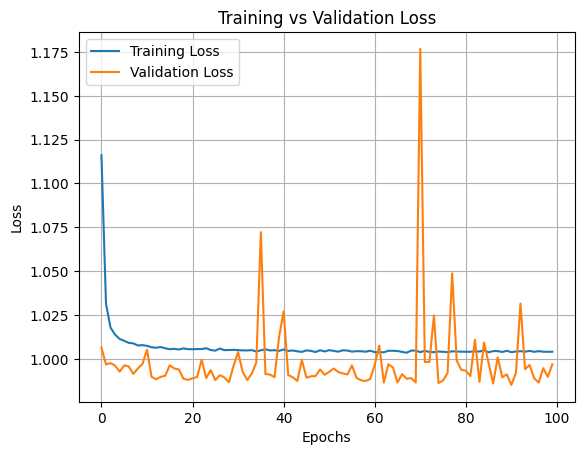

In [22]:
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [23]:
model.eval()
X_tensor = X_val_tensor.to(device)
y = y_val.values
with torch.no_grad():
    logits = model(X_tensor)
    y_prob = torch.softmax(logits, dim=1).cpu().numpy()
    y_pred = np.argmax(y_prob, axis=1)

PermutationExplainer explainer: 1001it [01:04, 14.77it/s]                                                              


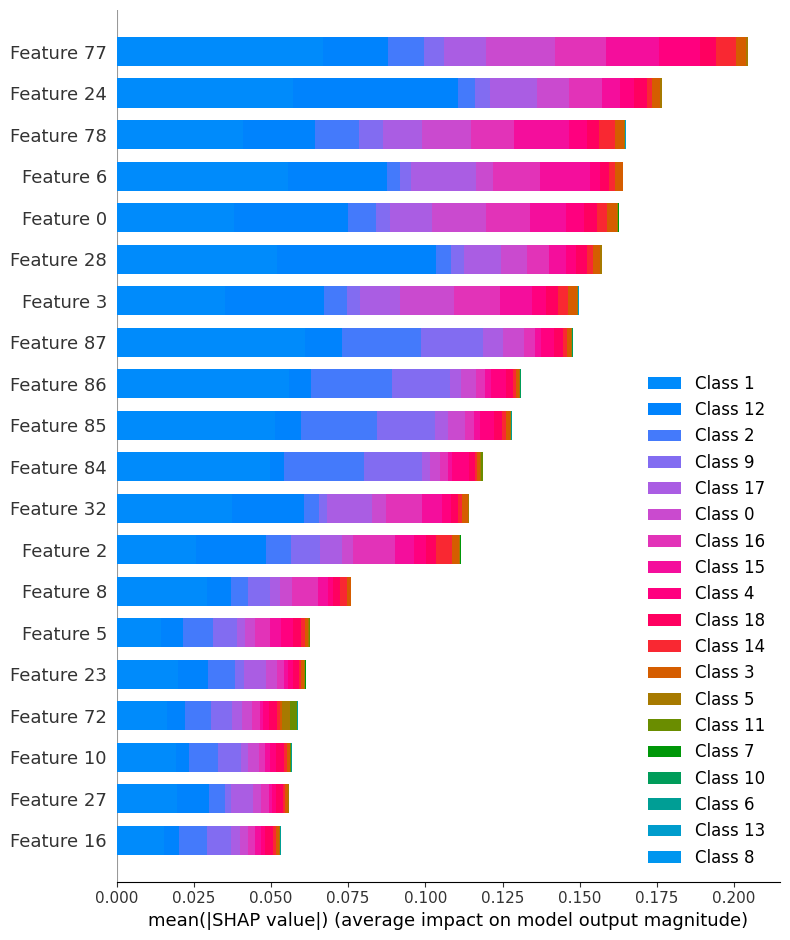

In [24]:
def predict_fn(X):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if not isinstance(X, np.ndarray):
        X = X.values
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    with torch.no_grad():
        outputs = torch.softmax(model(X_tensor), dim=1)
    return outputs.cpu().numpy()
    
rng = np.random.default_rng(42)
X_sample = X.sample(1000, random_state=42).values
explainer = shap.Explainer(predict_fn, X_sample)
shap_values = explainer(X_sample)
shap.summary_plot(shap_values, X_sample, rng=rng)

In [25]:
print("Accuracy:", accuracy_score(y, y_pred))
print("Weighted F1:", f1_score(y, y_pred, average='weighted'))
print("Macro F1:", f1_score(y, y_pred, average='macro'))
print("ROC-AUC:", roc_auc_score(y, y_prob, multi_class="ovr", average="weighted"))

Accuracy: 0.7593402777777778
Weighted F1: 0.7206561770337742
Macro F1: 0.4715550843697033
ROC-AUC: 0.9890693792455496


In [26]:
print(classification_report(y, y_pred, target_names=le.classes_))

               precision    recall  f1-score   support

       BENIGN       1.00      1.00      1.00     28800
    DrDoS_DNS       0.90      0.02      0.05      1600
   DrDoS_LDAP       0.50      0.00      0.00      1600
  DrDoS_MSSQL       0.44      0.11      0.17      1600
    DrDoS_NTP       0.98      0.99      0.99      1600
DrDoS_NetBIOS       0.92      0.03      0.05      1600
   DrDoS_SNMP       0.38      0.06      0.10      1600
   DrDoS_SSDP       0.30      0.02      0.04      1600
    DrDoS_UDP       0.28      0.85      0.42      1600
         LDAP       0.25      0.97      0.40      1600
        MSSQL       0.49      0.84      0.62      1600
      NetBIOS       0.37      0.99      0.53      1600
      Portmap       0.99      0.21      0.34      1600
          Syn       1.00      0.99      0.99      1600
         TFTP       0.93      1.00      0.96      1600
          UDP       0.00      0.00      0.00      1600
      UDP-lag       0.34      0.27      0.30      1600
       UD

C:\Users\Aristophanies\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Aristophanies\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Aristophanies\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod